Norma H originale:       300.00499995833405
Norma H scalata (k=5):   1500.02499979167
Fattore tra le norme:    4.999999999999999


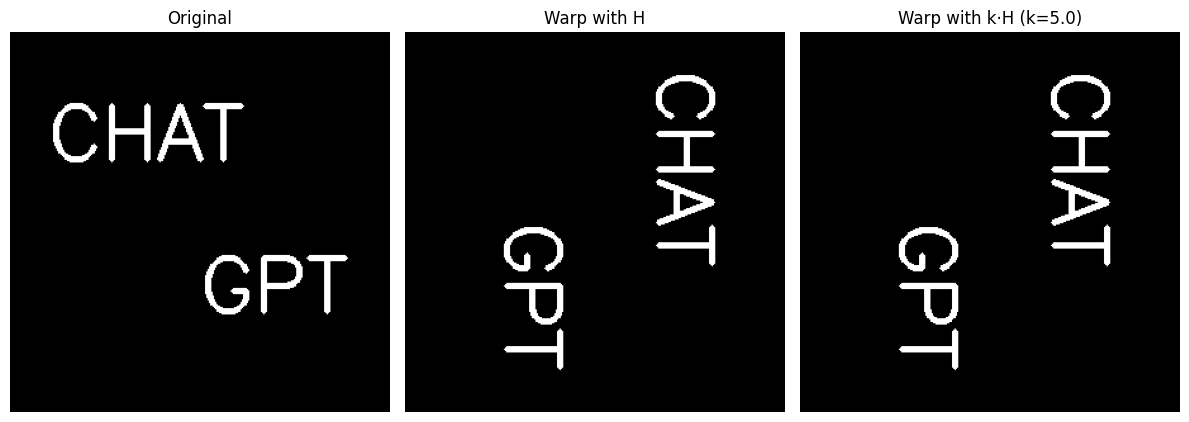

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Crea immagine asimmetrica
image = np.zeros((300, 300), dtype=np.uint8)
cv2.putText(image, "CHAT", (30, 100), cv2.FONT_HERSHEY_SIMPLEX, 2, 255, 4)
cv2.putText(image, "GPT", (150, 220), cv2.FONT_HERSHEY_SIMPLEX, 2, 255, 4)

# 2. Definisci omografia: rotazione di 90° attorno al centro
theta = np.pi / 2  # 90°
cos_t, sin_t = np.cos(theta), np.sin(theta)
cx, cy = image.shape[1] // 2, image.shape[0] // 2  # centro

R = np.array([
    [cos_t, -sin_t, 0],
    [sin_t,  cos_t, 0],
    [0,       0,    1]
], dtype=np.float64)

T1 = np.array([[1, 0, -cx], [0, 1, -cy], [0, 0, 1]])
T2 = np.array([[1, 0,  cx], [0, 1,  cy], [0, 0, 1]])
H = T2 @ R @ T1  # omografia "standard"

# 3. Crea H scalata
k = 5.0
H_scaled = k * H

# 4. Calcola le norme
norm_H = np.linalg.norm(H)
norm_H_scaled = np.linalg.norm(H_scaled)

print("Norma H originale:      ", norm_H)
print("Norma H scalata (k=5):  ", norm_H_scaled)
print("Fattore tra le norme:   ", norm_H_scaled / norm_H)

# 5. Applica entrambe le trasformazioni
warped = cv2.warpPerspective(image, H, (300, 300))
warped_scaled = cv2.warpPerspective(image, H_scaled, (300, 300))

# 6. Visualizza i risultati
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
axs[0].imshow(image, cmap='gray')
axs[0].set_title("Original")

axs[1].imshow(warped, cmap='gray')
axs[1].set_title("Warp with H")

axs[2].imshow(warped_scaled, cmap='gray')
axs[2].set_title("Warp with k·H (k={})".format(k))

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()